# Speech Emotion Recognition - Training Notebook

This notebook trains 6 models to detect emotion from speech audio.
Dataset: RAVDESS (1440 speech recordings, 8 emotions, 24 actors)

Run all cells from top to bottom. After this, launch the app with:
    streamlit run app.py


## 1. Install Libraries

In [1]:
import subprocess, sys

libs = [
    "kagglehub", "librosa", "soundfile",
    "scikit-learn", "xgboost",
    "matplotlib", "seaborn", "tqdm",
]
for lib in libs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", lib, "-q"])

# Install TensorFlow (use tensorflow-cpu if you don't have a GPU)
try:
    import tensorflow as tf
    print("TensorFlow already installed:", tf.__version__)
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow-cpu", "-q"])
    import tensorflow as tf
    print("Installed TensorFlow:", tf.__version__)

print("All libraries installed successfully")

TensorFlow already installed: 2.20.0
All libraries installed successfully


## 2. Import Everything

In [2]:
import os
import glob
import pickle
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

import librosa
import librosa.display
import librosa.effects
import soundfile as sf

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("librosa:", librosa.__version__)

Python: 3.12.13
NumPy: 2.0.2
TensorFlow: 2.20.0
librosa: 0.11.0


## 3. Settings and Paths

In [3]:
import sys

# Folders
MODELS_DIR    = "models"
PROCESSED_DIR = os.path.join("artifacts", "processed")
PLOTS_DIR     = os.path.join("artifacts", "plots")

for folder in [MODELS_DIR, PROCESSED_DIR, PLOTS_DIR]:
    os.makedirs(folder, exist_ok=True)

# Audio settings
SAMPLE_RATE  = 22050   # Hz
DURATION     = 4       # seconds to load per clip
N_MFCC       = 40      # number of MFCC coefficients
N_MELS       = 128     # mel spectrogram bins
N_CHROMA     = 12      # chroma features
HOP_LENGTH   = 512
N_FFT        = 2048
FIXED_FRAMES = 128     # fixed time length for 2D feature arrays

# RAVDESS emotion codes in the filename
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

EMOTIONS   = sorted(EMOTION_MAP.values())
N_CLASSES  = len(EMOTIONS)
LABEL_MAP  = {e: i for i, e in enumerate(EMOTIONS)}   # e.g. {"angry": 0, ...}
INV_LABEL  = {i: e for e, i in LABEL_MAP.items()}     # reverse lookup

# Training settings
TEST_SIZE   = 0.20
VAL_SIZE    = 0.10
EPOCHS      = 100
BATCH_SIZE  = 32
LEARNING_RATE = 0.001
PATIENCE    = 15       # early stopping patience
DROPOUT     = 0.3

print("Emotions:", EMOTIONS)
print("Label map:", LABEL_MAP)

Emotions: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Label map: {'angry': 0, 'calm': 1, 'disgust': 2, 'fearful': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprised': 7}


## 4. Download RAVDESS Dataset

In [4]:
import kagglehub

# Downloads to ~/.cache/kagglehub/... and returns the local path
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Dataset path:", path)

# Find all wav files
wav_files = glob.glob(f"{path}/**/*.wav", recursive=True)
print("Total wav files found:", len(wav_files))

100%|██████████| 429M/429M [00:06<00:00, 72.5MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1
Total wav files found: 2880


## 5. Parse Filenames and Build a Catalogue

In [5]:
# RAVDESS filename format:
# 03-01-{emotion}-{intensity}-{statement}-{repetition}-{actor}.wav
# modality 03 = audio-only speech (we skip song tracks)

def get_label(filepath):
    name  = os.path.basename(filepath)
    parts = name.replace(".wav", "").split("-")
    if len(parts) < 7:
        return None
    modality     = parts[0]
    emotion_code = parts[2]
    if modality != "03":
        return None
    return EMOTION_MAP.get(emotion_code)

catalogue = []
skipped   = 0

for fp in wav_files:
    label = get_label(fp)
    if label is None:
        skipped += 1
    else:
        catalogue.append({"path": fp, "emotion": label})

print("Samples in catalogue:", len(catalogue))
print("Skipped (song tracks):", skipped)

# Save catalogue for reuse
with open(os.path.join(PROCESSED_DIR, "catalogue.pkl"), "wb") as f:
    pickle.dump(catalogue, f)

# Show how many samples per emotion
dist = Counter(r["emotion"] for r in catalogue)
print()
print("Samples per emotion:")
for emo in sorted(dist):
    print(f"  {emo:<12}  {dist[emo]}")

Samples in catalogue: 2880
Skipped (song tracks): 0

Samples per emotion:
  angry         384
  calm          384
  disgust       384
  fearful       384
  happy         384
  neutral       192
  sad           384
  surprised     384


## 6. Visualize the Dataset

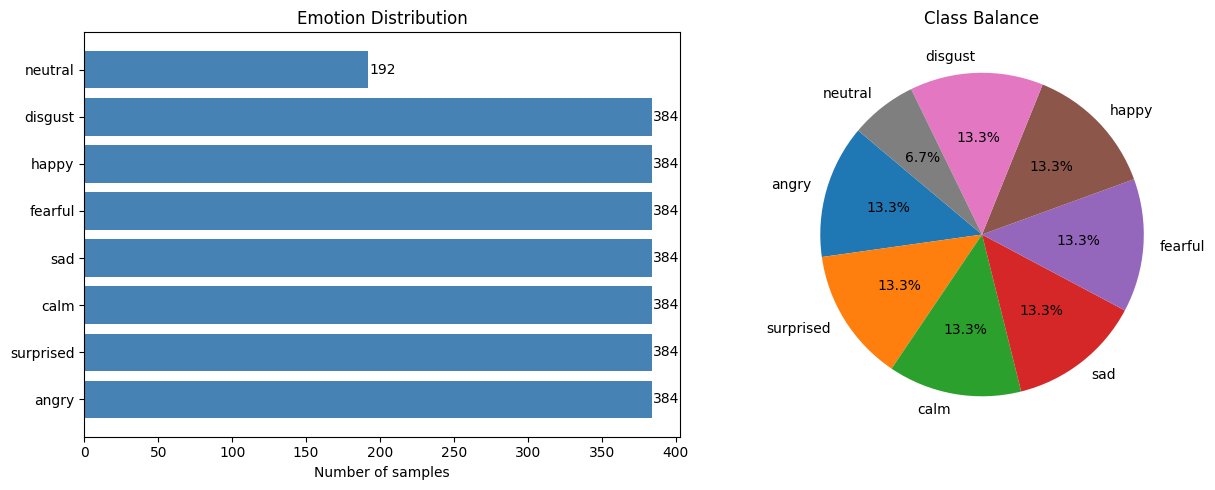

Plot saved.


In [6]:
dist = Counter(r["emotion"] for r in catalogue)
emotions_sorted = sorted(dist.keys(), key=lambda e: -dist[e])
counts = [dist[e] for e in emotions_sorted]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].barh(emotions_sorted, counts, color="steelblue")
axes[0].set_xlabel("Number of samples")
axes[0].set_title("Emotion Distribution")
for i, cnt in enumerate(counts):
    axes[0].text(cnt + 1, i, str(cnt), va="center")

# Pie chart
axes[1].pie(counts, labels=emotions_sorted, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Class Balance")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "emotion_distribution.png"), dpi=120)
plt.show()
print("Plot saved.")

## 7. Listen to Sample Audio (one clip per emotion)


ANGRY


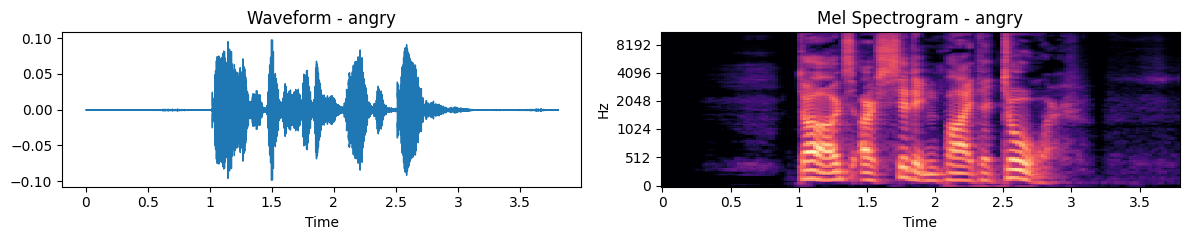


CALM


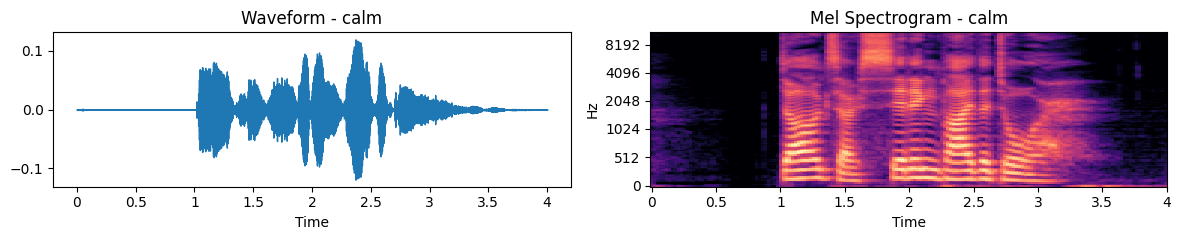


DISGUST


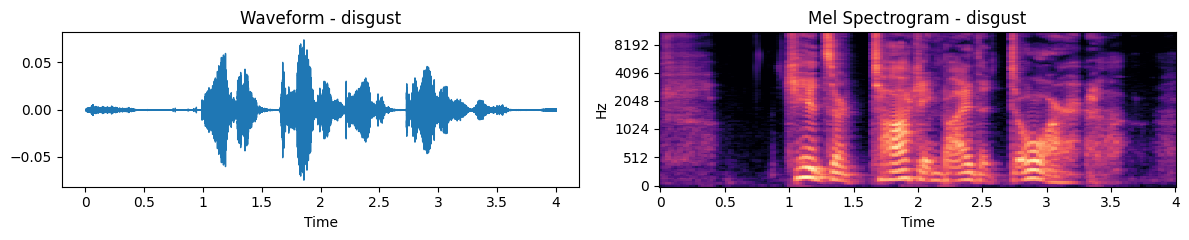


FEARFUL


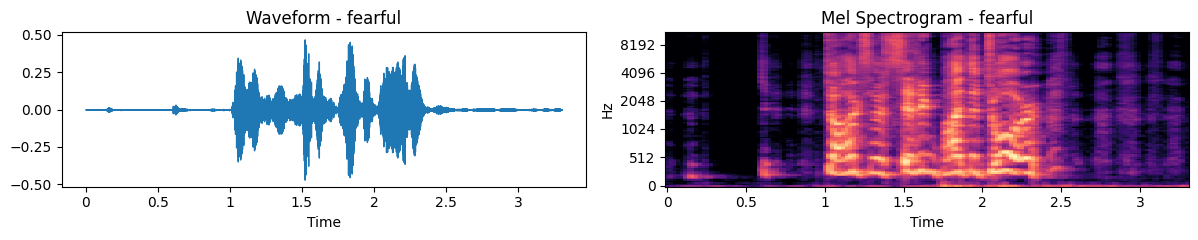


HAPPY


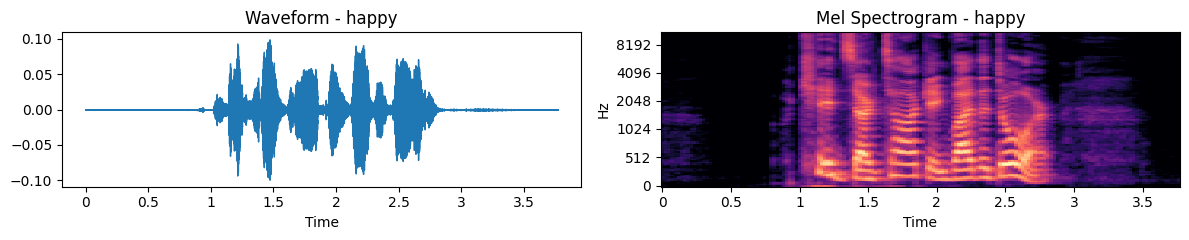


NEUTRAL


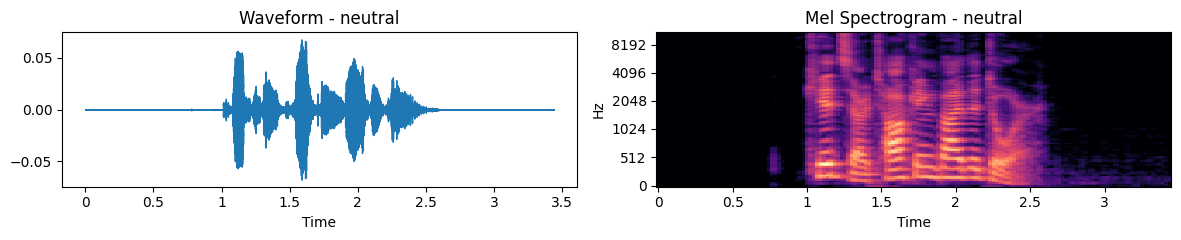


SAD


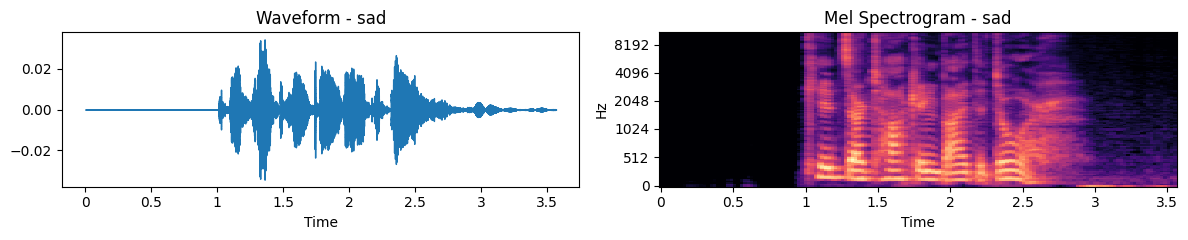


SURPRISED


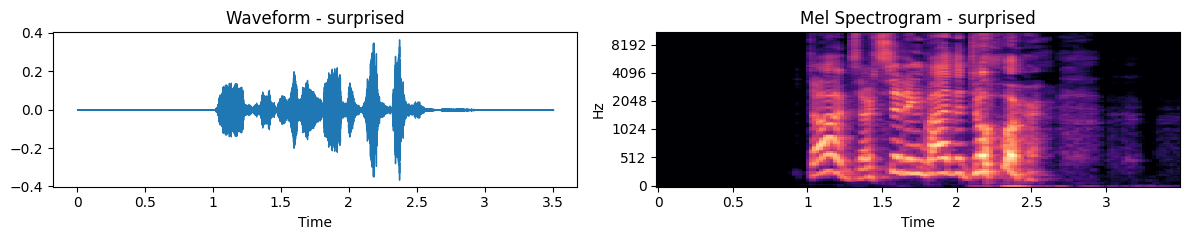

In [7]:
from IPython.display import Audio, display

# Pick one file per emotion
samples = {}
for rec in catalogue:
    if rec["emotion"] not in samples:
        samples[rec["emotion"]] = rec["path"]
    if len(samples) == N_CLASSES:
        break

for emotion in sorted(samples):
    print(f"\n{emotion.upper()}")
    y, sr = librosa.load(samples[emotion], sr=SAMPLE_RATE, duration=DURATION)

    fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Waveform - {emotion}")

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1], cmap="magma")
    axes[1].set_title(f"Mel Spectrogram - {emotion}")

    plt.tight_layout()
    plt.show()
    display(Audio(y, rate=sr))

## 8. Feature Extraction Functions

In [8]:
def load_and_clean_audio(path):
    # Load audio
    y, sr = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION, mono=True)

    # Trim silence from start and end
    y, _ = librosa.effects.trim(y, top_db=25)

    # Basic noise reduction using spectral gating
    S = np.abs(librosa.stft(y))
    noise_floor = np.mean(S[:, :10], axis=1, keepdims=True)
    mask = S > (noise_floor * 1.5)
    y = librosa.istft(S * mask)

    return y, sr


def pad_or_truncate(arr, target_length):
    # Make the time axis exactly target_length frames
    if arr.shape[-1] < target_length:
        pad_amount = target_length - arr.shape[-1]
        pad_config = [(0, 0)] * (arr.ndim - 1) + [(0, pad_amount)]
        arr = np.pad(arr, pad_config, mode="constant")
    else:
        arr = arr[..., :target_length]
    return arr


def extract_flat_features(path):
    # Returns a 1D feature vector combining several audio features
    y, sr = load_and_clean_audio(path)

    feature_parts = []

    # MFCC: captures spectral envelope (most important feature for speech)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta  = librosa.feature.delta(mfcc)        # velocity (rate of change)
    delta2 = librosa.feature.delta(mfcc, order=2)  # acceleration
    feature_parts.append(np.mean(mfcc, axis=1))
    feature_parts.append(np.std(mfcc, axis=1))
    feature_parts.append(np.mean(delta, axis=1))
    feature_parts.append(np.mean(delta2, axis=1))

    # Mel spectrogram: frequency representation matching human hearing
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    feature_parts.append(np.mean(mel_db, axis=1))

    # Chroma: pitch class information
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=N_CHROMA, n_fft=N_FFT, hop_length=HOP_LENGTH)
    feature_parts.append(np.mean(chroma, axis=1))

    # Zero crossing rate: how often signal changes sign (relates to noisiness)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)
    feature_parts.append(np.array([np.mean(zcr)]))

    # RMS energy: overall loudness
    rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
    feature_parts.append(np.array([np.mean(rms)]))

    # Spectral contrast: difference between peaks and valleys in the spectrum
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    feature_parts.append(np.mean(contrast, axis=1))

    # Tonnetz: tonal centroid features on harmonic component
    harmonic = librosa.effects.harmonic(y)
    tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=sr)
    feature_parts.append(np.mean(tonnetz, axis=1))

    return np.concatenate(feature_parts).astype(np.float32)


def extract_2d_mfcc(path):
    # Returns a 2D MFCC array of shape (N_MFCC, FIXED_FRAMES) for CNN/LSTM input
    y, sr = load_and_clean_audio(path)
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    return pad_or_truncate(mfcc, FIXED_FRAMES).astype(np.float32)


# Quick test
test_flat = extract_flat_features(catalogue[0]["path"])
test_2d   = extract_2d_mfcc(catalogue[0]["path"])
print("Flat feature vector length:", len(test_flat))
print("2D MFCC shape:", test_2d.shape)

Flat feature vector length: 315
2D MFCC shape: (40, 128)


## 9. Extract Features for All Samples (cached)

In [9]:
FEATURES_CACHE = os.path.join(PROCESSED_DIR, "features.pkl")

if os.path.exists(FEATURES_CACHE):
    print("Loading features from cache...")
    with open(FEATURES_CACHE, "rb") as f:
        feat_data = pickle.load(f)
    print("Loaded", len(feat_data["y"]), "samples from cache")
else:
    print("Extracting features for all", len(catalogue), "samples...")
    X_flat_list = []
    X_mfcc_list = []
    labels      = []
    errors      = 0

    for rec in tqdm(catalogue, desc="Feature extraction"):
        try:
            flat   = extract_flat_features(rec["path"])
            mfcc2d = extract_2d_mfcc(rec["path"])
            X_flat_list.append(flat)
            X_mfcc_list.append(mfcc2d)
            labels.append(rec["emotion"])
        except Exception as e:
            errors += 1

    feat_data = {
        "X_flat"    : np.array(X_flat_list, dtype=np.float32),
        "X_mfcc"    : np.array(X_mfcc_list, dtype=np.float32),
        "y"         : labels,
        "label_map" : LABEL_MAP,
    }

    with open(FEATURES_CACHE, "wb") as f:
        pickle.dump(feat_data, f)

    print("Done.", len(labels), "samples saved,", errors, "failed")

# Unpack
X_flat = feat_data["X_flat"]
X_mfcc = feat_data["X_mfcc"]
y_str  = feat_data["y"]
y_enc  = np.array([LABEL_MAP[e] for e in y_str], dtype=np.int32)

print("Flat features shape:", X_flat.shape)
print("MFCC 2D shape      :", X_mfcc.shape)
print("Total samples      :", len(y_enc))

Extracting features for all 2880 samples...


Feature extraction:   0%|          | 0/2880 [00:00<?, ?it/s]

Done. 2880 samples saved, 0 failed
Flat features shape: (2880, 315)
MFCC 2D shape      : (2880, 40, 128)
Total samples      : 2880


## 10. Save Label Map (needed by app.py)

In [10]:
label_map_path = os.path.join(PROCESSED_DIR, "label_map.pkl")
with open(label_map_path, "wb") as f:
    pickle.dump({"label_map": LABEL_MAP, "inv_label_map": INV_LABEL}, f)
print("Label map saved to", label_map_path)

Label map saved to artifacts/processed/label_map.pkl


## 11. Split Data into Train / Validation / Test

In [11]:
# First cut off the test set (20%)
X_f_trainval, X_f_test, X_m_trainval, X_m_test, y_trainval, y_test = train_test_split(
    X_flat, X_mfcc, y_enc,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y_enc
)

# From the remaining 80%, cut off validation (10% of total = 12.5% of 80%)
val_fraction = VAL_SIZE / (1.0 - TEST_SIZE)
X_f_train, X_f_val, X_m_train, X_m_val, y_train, y_val = train_test_split(
    X_f_trainval, X_m_trainval, y_trainval,
    test_size=val_fraction,
    random_state=42,
    stratify=y_trainval
)

print("Train:", len(y_train))
print("Val  :", len(y_val))
print("Test :", len(y_test))

Train: 2016
Val  : 288
Test : 576


## 12. Random Forest

In [12]:
rf_path = os.path.join(MODELS_DIR, "random_forest.pkl")

if os.path.exists(rf_path):
    with open(rf_path, "rb") as f:
        rf_model = pickle.load(f)
    print("Loaded Random Forest from cache")
else:
    print("Training Random Forest with hyperparameter search...")

    rf_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=0.95, random_state=42)),
        ("model",  RandomForestClassifier(random_state=42, n_jobs=-1))
    ])

    param_grid = {
        "model__n_estimators"    : [100, 200, 300],
        "model__max_depth"       : [None, 20, 30],
        "model__min_samples_split": [2, 5],
        "model__max_features"    : ["sqrt", "log2"],
    }

    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    search = RandomizedSearchCV(rf_pipeline, param_grid, n_iter=10,
                                scoring="f1_weighted", cv=cv, n_jobs=-1,
                                random_state=42, verbose=1)
    search.fit(X_f_train, y_train)
    rf_model = search.best_estimator_

    with open(rf_path, "wb") as f:
        pickle.dump(rf_model, f)
    print("Best CV F1:", round(search.best_score_, 4))

rf_pred  = rf_model.predict(X_f_test)
rf_proba = rf_model.predict_proba(X_f_test)
rf_acc   = accuracy_score(y_test, rf_pred)
rf_f1    = f1_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_auc   = roc_auc_score(label_binarize(y_test, classes=range(N_CLASSES)),
                          rf_proba, multi_class="ovr", average="macro")

print("Random Forest ->  Acc:", round(rf_acc, 4),
      "  F1:", round(rf_f1, 4), "  AUC:", round(rf_auc, 4))

Training Random Forest with hyperparameter search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV F1: 0.7339
Random Forest ->  Acc: 0.849   F1: 0.848   AUC: 0.9914


## 13. SVM

In [13]:
svm_path = os.path.join(MODELS_DIR, "svm.pkl")

if os.path.exists(svm_path):
    with open(svm_path, "rb") as f:
        svm_model = pickle.load(f)
    print("Loaded SVM from cache")
else:
    print("Training SVM...")

    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=0.95, random_state=42)),
        ("model",  SVC(kernel="rbf", probability=True, random_state=42))
    ])

    param_grid = {
        "model__C"    : [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.001, 0.01],
    }

    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    search = RandomizedSearchCV(svm_pipeline, param_grid, n_iter=8,
                                scoring="f1_weighted", cv=cv, n_jobs=-1,
                                random_state=42, verbose=1)
    search.fit(X_f_train, y_train)
    svm_model = search.best_estimator_

    with open(svm_path, "wb") as f:
        pickle.dump(svm_model, f)
    print("Best CV F1:", round(search.best_score_, 4))

svm_pred  = svm_model.predict(X_f_test)
svm_proba = svm_model.predict_proba(X_f_test)
svm_acc   = accuracy_score(y_test, svm_pred)
svm_f1    = f1_score(y_test, svm_pred, average="weighted", zero_division=0)
svm_auc   = roc_auc_score(label_binarize(y_test, classes=range(N_CLASSES)),
                           svm_proba, multi_class="ovr", average="macro")

print("SVM ->  Acc:", round(svm_acc, 4),
      "  F1:", round(svm_f1, 4), "  AUC:", round(svm_auc, 4))

Training SVM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV F1: 0.7926
SVM ->  Acc: 0.8958   F1: 0.8949   AUC: 0.9926


## 14. XGBoost

In [14]:
xgb_path = os.path.join(MODELS_DIR, "xgboost.pkl")

if os.path.exists(xgb_path):
    with open(xgb_path, "rb") as f:
        xgb_model = pickle.load(f)
    print("Loaded XGBoost from cache")
else:
    print("Training XGBoost...")

    xgb_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=0.95, random_state=42)),
        ("model",  XGBClassifier(objective="multi:softprob", num_class=N_CLASSES,
                                 eval_metric="mlogloss", random_state=42,
                                 n_jobs=-1, verbosity=0))
    ])

    param_grid = {
        "model__n_estimators" : [100, 200, 300],
        "model__max_depth"    : [4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample"    : [0.7, 0.8, 1.0],
    }

    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    search = RandomizedSearchCV(xgb_pipeline, param_grid, n_iter=8,
                                scoring="f1_weighted", cv=cv, n_jobs=-1,
                                random_state=42, verbose=1)
    search.fit(X_f_train, y_train)
    xgb_model = search.best_estimator_

    with open(xgb_path, "wb") as f:
        pickle.dump(xgb_model, f)
    print("Best CV F1:", round(search.best_score_, 4))

xgb_pred  = xgb_model.predict(X_f_test)
xgb_proba = xgb_model.predict_proba(X_f_test)
xgb_acc   = accuracy_score(y_test, xgb_pred)
xgb_f1    = f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
xgb_auc   = roc_auc_score(label_binarize(y_test, classes=range(N_CLASSES)),
                           xgb_proba, multi_class="ovr", average="macro")

print("XGBoost ->  Acc:", round(xgb_acc, 4),
      "  F1:", round(xgb_f1, 4), "  AUC:", round(xgb_auc, 4))

Training XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV F1: 0.7369
XGBoost ->  Acc: 0.8576   F1: 0.8573   AUC: 0.9905


## 15. CNN (Convolutional Neural Network)

Training CNN...


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 128, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,304 (1.68 MB)

 Trainable params: 438,408 (1.67 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.3085 - loss: 1.7488 - val_accuracy: 0.1319 - val_loss: 5.3034 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4191 - loss: 1.5290 - val_accuracy: 0.1424 - val_loss: 4.1407 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4578 - loss: 1.4219 - val_accuracy: 0.2396 - val_loss: 2.6656 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4945 - loss: 1.3394 - val_accuracy: 0.2535 - val_loss: 2.5229 - learning_rate: 0.0010
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5218 - loss: 1.2769 - val_accuracy: 0.4132 - val_loss: 1.5172 - learning_rate: 0.0010
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5471 - loss: 1.2154 - val_accuracy: 0.4688 - val_loss: 1.3317 - learning_rate: 0.0010
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5605 - loss: 1.1728 -

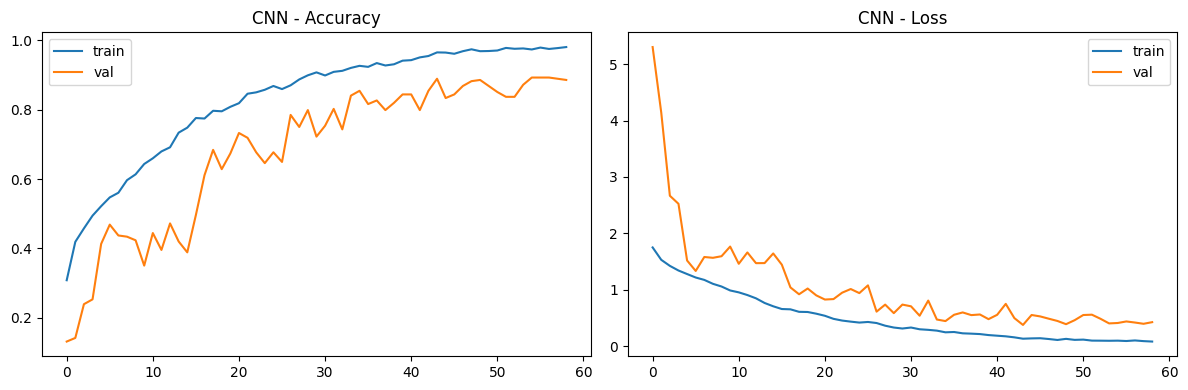

CNN ->  Acc: 0.8958   F1: 0.8964   AUC: 0.9894


In [15]:
cnn_path = os.path.join(MODELS_DIR, "cnn.keras")

if os.path.exists(cnn_path):
    cnn_model = keras.models.load_model(cnn_path)
    print("Loaded CNN from cache")
else:
    print("Training CNN...")

    # Add channel dimension: (N, 40, 128) -> (N, 40, 128, 1)
    X_train_cnn = X_m_train[..., np.newaxis]
    X_val_cnn   = X_m_val[..., np.newaxis]

    model = keras.Sequential([
        keras.Input(shape=X_train_cnn.shape[1:]),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(DROPOUT),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(DROPOUT),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(DROPOUT),

        layers.Dense(256, activation="relu"),
        layers.Dropout(DROPOUT),
        layers.Dense(N_CLASSES, activation="softmax"),
    ], name="CNN")

    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=PATIENCE // 2, verbose=1),
    ]

    history = model.fit(
        X_train_cnn, y_train,
        validation_data=(X_val_cnn, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    model.save(cnn_path)
    cnn_model = model

    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title("CNN - Accuracy")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title("CNN - Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "cnn_training.png"), dpi=120)
    plt.show()

cnn_test_input = X_m_test[..., np.newaxis]
cnn_proba = cnn_model.predict(cnn_test_input, verbose=0)
cnn_pred  = np.argmax(cnn_proba, axis=1)
cnn_acc   = accuracy_score(y_test, cnn_pred)
cnn_f1    = f1_score(y_test, cnn_pred, average="weighted", zero_division=0)
cnn_auc   = roc_auc_score(label_binarize(y_test, classes=range(N_CLASSES)),
                           cnn_proba, multi_class="ovr", average="macro")

print("CNN ->  Acc:", round(cnn_acc, 4),
      "  F1:", round(cnn_f1, 4), "  AUC:", round(cnn_auc, 4))

## 16. Bi-LSTM

Training Bi-LSTM...


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       173,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,952 (1.35 MB)

 Trainable params: 354,952 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.2153 - loss: 1.9765 - val_accuracy: 0.2431 - val_loss: 1.8933 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3259 - loss: 1.7344 - val_accuracy: 0.3125 - val_loss: 1.7646 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3571 - loss: 1.6415 - val_accuracy: 0.3542 - val_loss: 1.7027 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4107 - loss: 1.5134 - val_accuracy: 0.4236 - val_loss: 1.5560 - learning_rate: 0.0010
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4831 - loss: 1.3756 - val_accuracy: 0.5069 - val_loss: 1.3654 - learning_rate: 0.0010
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5293 - loss: 1.2661 - val_accuracy: 0.5104 - val_loss: 1.3262 - learning_rate: 0.0010
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5680 - loss: 1.1701 - 

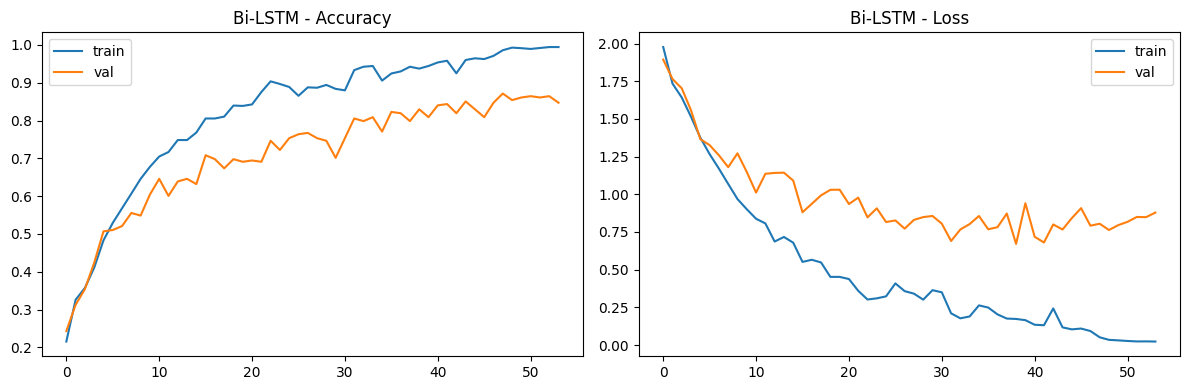

Bi-LSTM ->  Acc: 0.8576   F1: 0.8579   AUC: 0.9761


In [16]:
lstm_path = os.path.join(MODELS_DIR, "lstm.keras")

if os.path.exists(lstm_path):
    lstm_model = keras.models.load_model(lstm_path)
    print("Loaded Bi-LSTM from cache")
else:
    print("Training Bi-LSTM...")

    # Transpose: (N, n_mfcc, time) -> (N, time, n_mfcc)
    # LSTM expects sequence input: (batch, timesteps, features)
    X_train_lstm = np.transpose(X_m_train, (0, 2, 1))
    X_val_lstm   = np.transpose(X_m_val, (0, 2, 1))

    model = keras.Sequential([
        keras.Input(shape=X_train_lstm.shape[1:]),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Dropout(DROPOUT),
        layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
        layers.Dropout(DROPOUT),
        layers.Dense(128, activation="relu"),
        layers.Dropout(DROPOUT),
        layers.Dense(N_CLASSES, activation="softmax"),
    ], name="BiLSTM")

    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=PATIENCE // 2, verbose=1),
    ]

    history = model.fit(
        X_train_lstm, y_train,
        validation_data=(X_val_lstm, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    model.save(lstm_path)
    lstm_model = model

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title("Bi-LSTM - Accuracy")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title("Bi-LSTM - Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "lstm_training.png"), dpi=120)
    plt.show()

lstm_test_input = np.transpose(X_m_test, (0, 2, 1))
lstm_proba = lstm_model.predict(lstm_test_input, verbose=0)
lstm_pred  = np.argmax(lstm_proba, axis=1)
lstm_acc   = accuracy_score(y_test, lstm_pred)
lstm_f1    = f1_score(y_test, lstm_pred, average="weighted", zero_division=0)
lstm_auc   = roc_auc_score(label_binarize(y_test, classes=range(N_CLASSES)),
                            lstm_proba, multi_class="ovr", average="macro")

print("Bi-LSTM ->  Acc:", round(lstm_acc, 4),
      "  F1:", round(lstm_f1, 4), "  AUC:", round(lstm_auc, 4))

## 17. CNN-LSTM Hybrid

Training CNN-LSTM Hybrid...


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 128, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 128, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 128, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 128, 1280)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,552,008 (5.92 MB)

 Trainable params: 1,551,624 (5.92 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.1880 - loss: 2.0631 - val_accuracy: 0.1215 - val_loss: 2.0144 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.2743 - loss: 1.8621 - val_accuracy: 0.1910 - val_loss: 2.0142 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.3343 - loss: 1.7430 - val_accuracy: 0.2500 - val_loss: 1.9193 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3175 - loss: 1.7368 - val_accuracy: 0.2882 - val_loss: 1.8252 - learning_rate: 0.0010
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.3343 - loss: 1.7130 - val_accuracy: 0.2951 - val_loss: 1.7472 - learning_rate: 0.0010
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.3482 - loss: 1.6672 - val_accuracy: 0.3681 - val_loss: 1.6394 - learning_rate: 0.0010
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.3656 - loss: 1.6590 - 

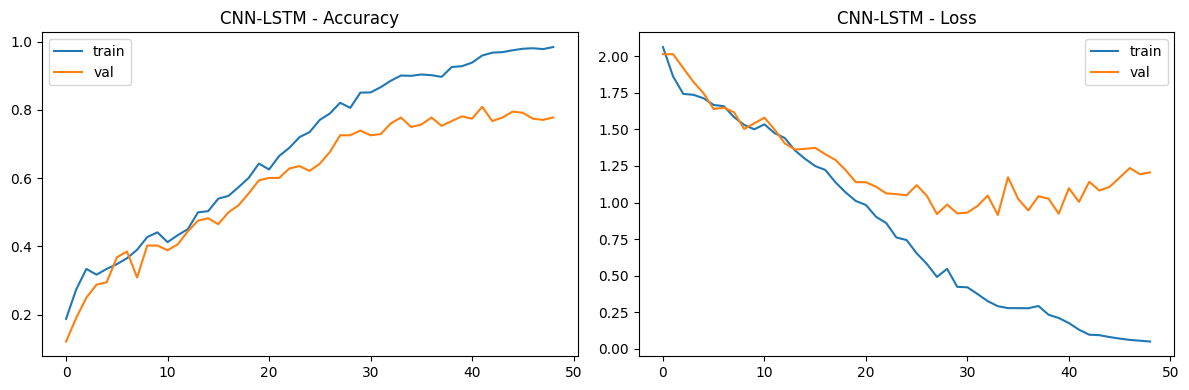

CNN-LSTM ->  Acc: 0.8142   F1: 0.8111   AUC: 0.9624


In [17]:
cnn_lstm_path = os.path.join(MODELS_DIR, "cnn_lstm.keras")

if os.path.exists(cnn_lstm_path):
    cnn_lstm_model = keras.models.load_model(cnn_lstm_path)
    print("Loaded CNN-LSTM from cache")
else:
    print("Training CNN-LSTM Hybrid...")

    # CNN extracts local patterns from the spectrogram,
    # then LSTM reads the sequence of CNN-extracted features over time.
    X_train_cl = X_m_train[..., np.newaxis]
    X_val_cl   = X_m_val[..., np.newaxis]

    inp = keras.Input(shape=X_train_cl.shape[1:])

    # CNN block - reduces frequency dimension, keeps time
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)   # pool frequency, keep time

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)

    # Reshape so LSTM gets (batch, time, features)
    sh = keras.backend.int_shape(x)
    x  = layers.Reshape((sh[2], sh[1] * sh[3]))(x)

    # LSTM block
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(N_CLASSES, activation="softmax")(x)

    model = keras.Model(inp, out, name="CNN_LSTM")
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=PATIENCE // 2, verbose=1),
    ]

    history = model.fit(
        X_train_cl, y_train,
        validation_data=(X_val_cl, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    model.save(cnn_lstm_path)
    cnn_lstm_model = model

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title("CNN-LSTM - Accuracy")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title("CNN-LSTM - Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "cnn_lstm_training.png"), dpi=120)
    plt.show()

cl_test_input = X_m_test[..., np.newaxis]
cl_proba = cnn_lstm_model.predict(cl_test_input, verbose=0)
cl_pred  = np.argmax(cl_proba, axis=1)
cl_acc   = accuracy_score(y_test, cl_pred)
cl_f1    = f1_score(y_test, cl_pred, average="weighted", zero_division=0)
cl_auc   = roc_auc_score(label_binarize(y_test, classes=range(N_CLASSES)),
                          cl_proba, multi_class="ovr", average="macro")

print("CNN-LSTM ->  Acc:", round(cl_acc, 4),
      "  F1:", round(cl_f1, 4), "  AUC:", round(cl_auc, 4))

## 18. Compare All Models

In [18]:
# Collect all results in one list for easy comparison
results = [
    {"name": "CNN-LSTM", "acc": cl_acc,   "f1": cl_f1,   "auc": cl_auc,
     "pred": cl_pred,   "proba": cl_proba},
    {"name": "CNN",      "acc": cnn_acc,  "f1": cnn_f1,  "auc": cnn_auc,
     "pred": cnn_pred,  "proba": cnn_proba},
    {"name": "Bi-LSTM",  "acc": lstm_acc, "f1": lstm_f1, "auc": lstm_auc,
     "pred": lstm_pred, "proba": lstm_proba},
    {"name": "XGBoost",  "acc": xgb_acc,  "f1": xgb_f1,  "auc": xgb_auc,
     "pred": xgb_pred,  "proba": xgb_proba},
    {"name": "SVM",      "acc": svm_acc,  "f1": svm_f1,  "auc": svm_auc,
     "pred": svm_pred,  "proba": svm_proba},
    {"name": "Random Forest", "acc": rf_acc, "f1": rf_f1, "auc": rf_auc,
     "pred": rf_pred,   "proba": rf_proba},
]
results.sort(key=lambda r: r["f1"], reverse=True)

print(f"{'Model':<18}  {'Accuracy':>9}  {'F1-Weighted':>12}  {'ROC-AUC':>9}")
print("-" * 55)
for r in results:
    marker = " <-- best" if r == results[0] else ""
    print(f"{r['name']:<18}  {r['acc']:>9.4f}  {r['f1']:>12.4f}  {r['auc']:>9.4f}{marker}")

# Save to JSON for the README / GitHub
summary = [{"name": r["name"], "accuracy": round(r["acc"], 4),
            "f1_weighted": round(r["f1"], 4), "roc_auc": round(r["auc"], 4)}
           for r in results]
with open(os.path.join("artifacts", "model_comparison.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved to artifacts/model_comparison.json")

Model                Accuracy   F1-Weighted    ROC-AUC
-------------------------------------------------------
CNN                    0.8958        0.8964     0.9894 <-- best
SVM                    0.8958        0.8949     0.9926
Bi-LSTM                0.8576        0.8579     0.9761
XGBoost                0.8576        0.8573     0.9905
Random Forest          0.8490        0.8480     0.9914
CNN-LSTM               0.8142        0.8111     0.9624

Saved to artifacts/model_comparison.json


## 19. Performance Chart

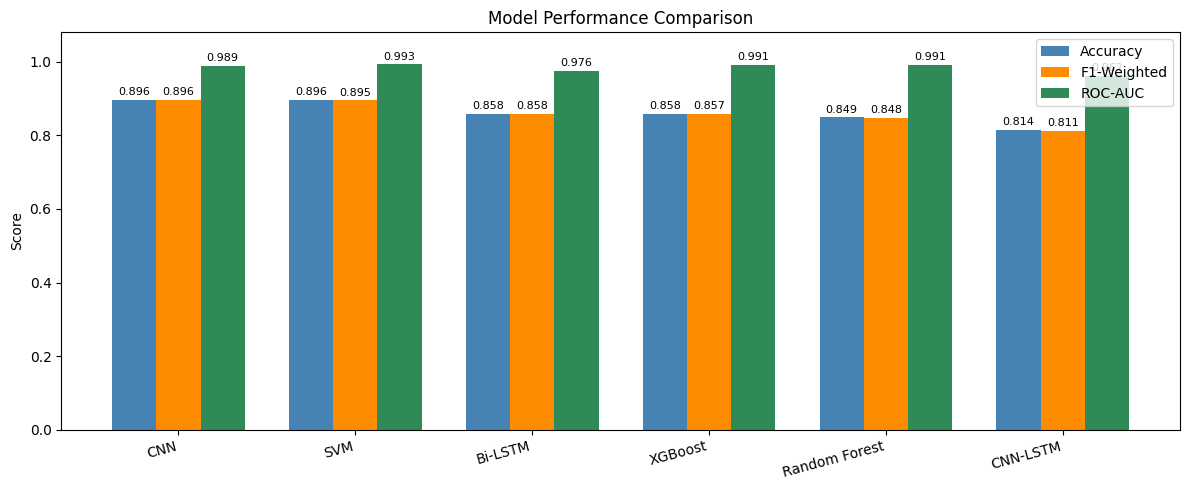

In [19]:
names = [r["name"] for r in results]
accs  = [r["acc"] for r in results]
f1s   = [r["f1"]  for r in results]
aucs  = [r["auc"] for r in results]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w,   accs, w, label="Accuracy",    color="steelblue")
ax.bar(x,       f1s,  w, label="F1-Weighted", color="darkorange")
ax.bar(x + w,   aucs, w, label="ROC-AUC",     color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "performance_comparison.png"), dpi=150)
plt.show()

## 20. Confusion Matrices

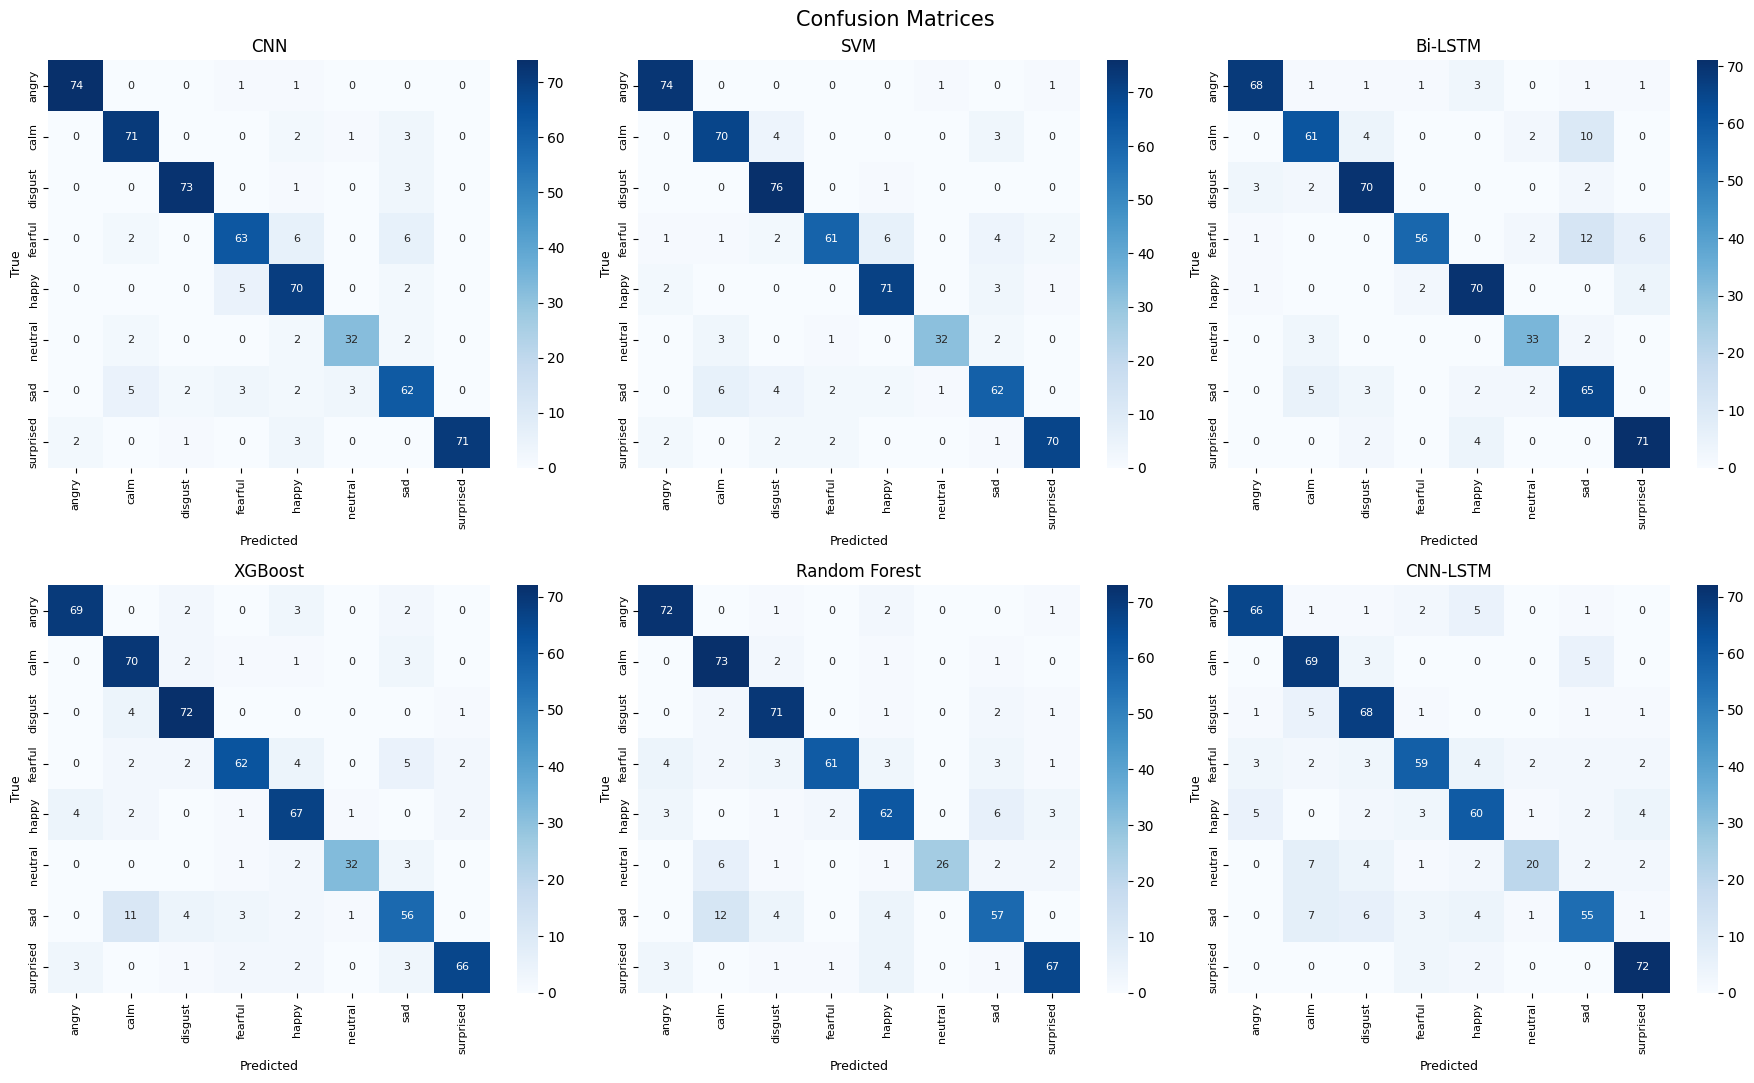

Saved to artifacts/plots


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Confusion Matrices", fontsize=15)

for ax, r in zip(axes.flat, results):
    cm = confusion_matrix(y_test, r["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax, annot_kws={"size": 8})
    ax.set_title(r["name"])
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "all_confusion_matrices.png"), dpi=120)
plt.show()
print("Saved to", PLOTS_DIR)

## 21. ROC Curves

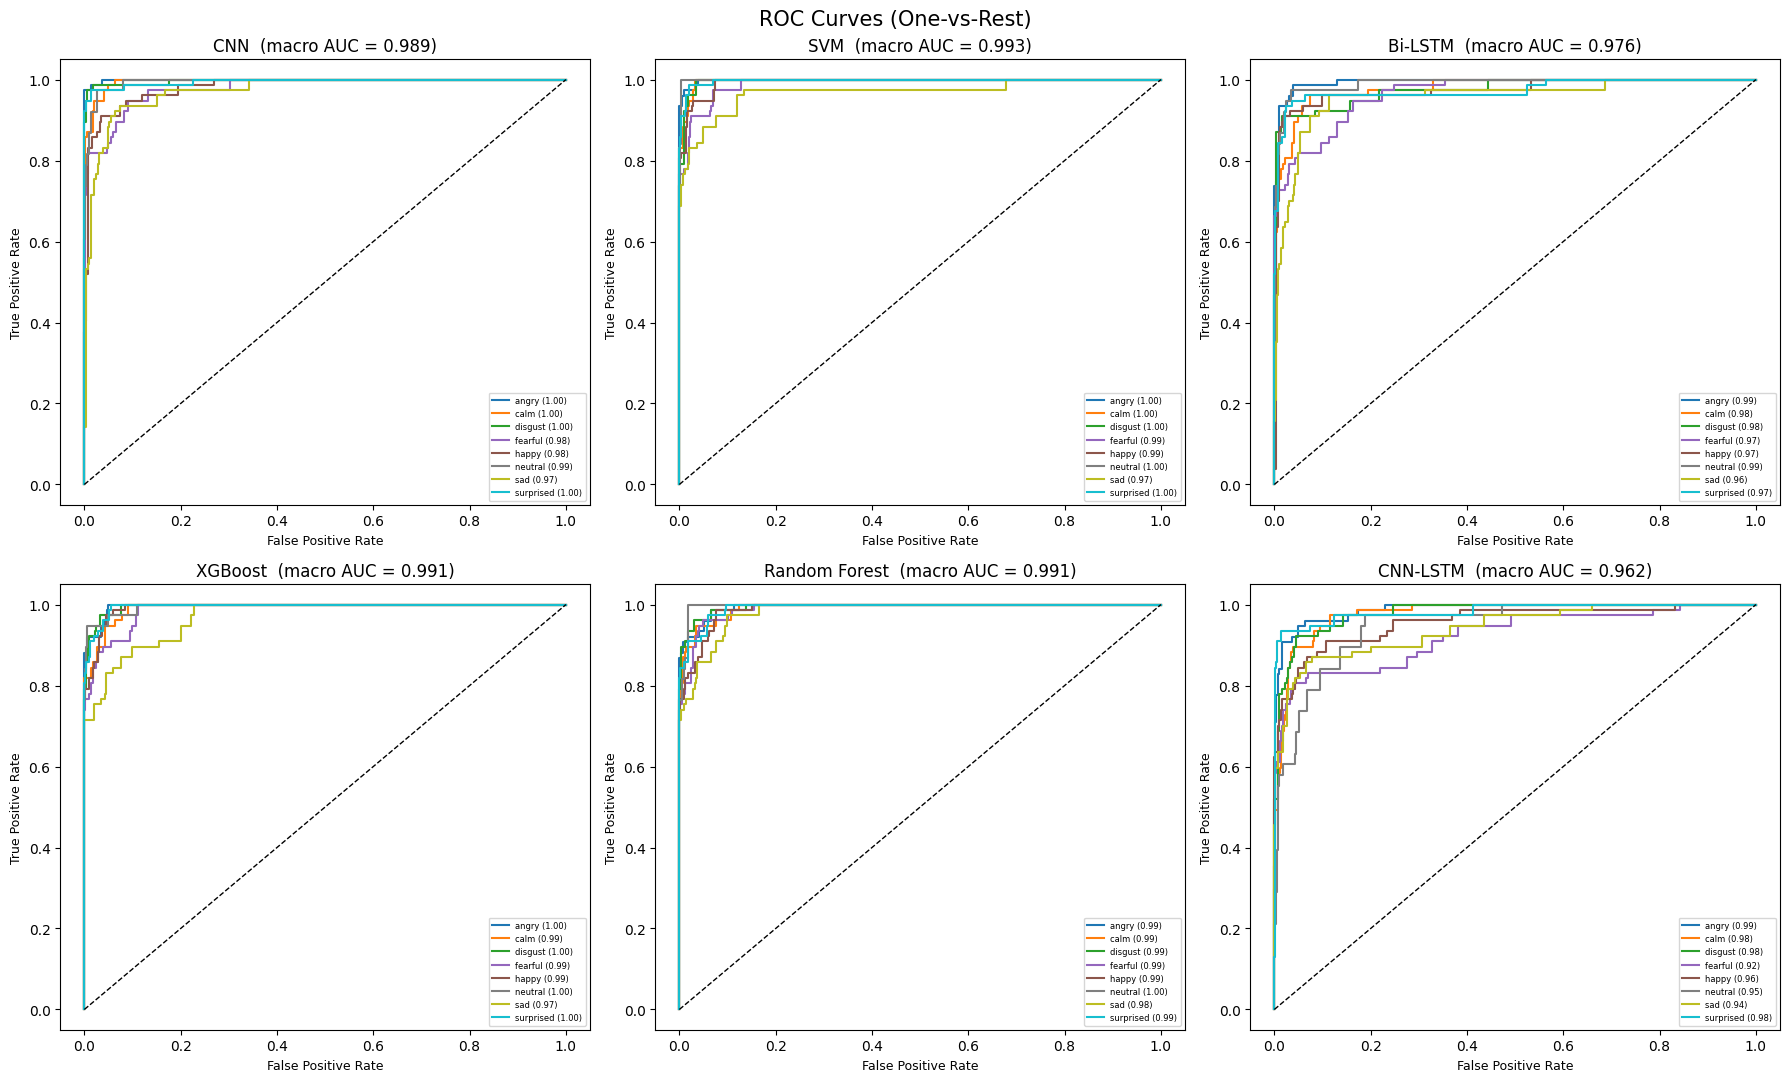

In [21]:
y_bin  = label_binarize(y_test, classes=list(range(N_CLASSES)))
colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("ROC Curves (One-vs-Rest)", fontsize=15)

for ax, r in zip(axes.flat, results):
    for i, (emo, color) in enumerate(zip(EMOTIONS, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], r["proba"][:, i])
        roc_i = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5, label=f"{emo} ({roc_i:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"{r['name']}  (macro AUC = {r['auc']:.3f})")
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate", fontsize=9)
    ax.legend(loc="lower right", fontsize=6)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "all_roc_curves.png"), dpi=120)
plt.show()

## 22. Detailed Classification Report (Best Model)

In [22]:
best = results[0]
print("Best model:", best["name"])
print("Accuracy  :", round(best["acc"], 4))
print("F1-W      :", round(best["f1"],  4))
print("ROC-AUC   :", round(best["auc"], 4))
print()
print(classification_report(y_test, best["pred"], target_names=EMOTIONS, zero_division=0))

Best model: CNN
Accuracy  : 0.8958
F1-W      : 0.8964
ROC-AUC   : 0.9894

              precision    recall  f1-score   support

       angry       0.97      0.97      0.97        76
        calm       0.89      0.92      0.90        77
     disgust       0.96      0.95      0.95        77
     fearful       0.88      0.82      0.85        77
       happy       0.80      0.91      0.85        77
     neutral       0.89      0.84      0.86        38
         sad       0.79      0.81      0.80        77
   surprised       1.00      0.92      0.96        77

    accuracy                           0.90       576
   macro avg       0.90      0.89      0.89       576
weighted avg       0.90      0.90      0.90       576



## 23. SHAP Feature Importance (Random Forest)

Computing SHAP values for Random Forest (this may take a minute)...


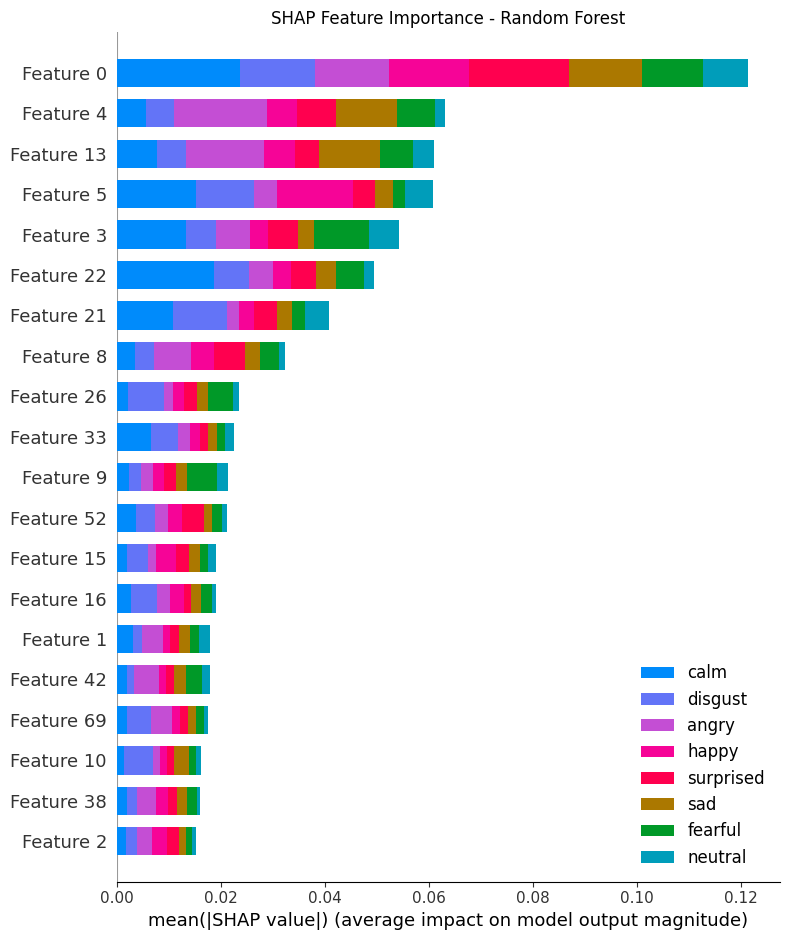

Saved SHAP plot.


In [23]:
try:
    import shap

    print("Computing SHAP values for Random Forest (this may take a minute)...")

    # Transform the test data through scaler and PCA first
    X_transformed  = rf_model[:-1].transform(X_f_test[:150])
    rf_estimator   = rf_model.named_steps["model"]

    explainer   = shap.TreeExplainer(rf_estimator)
    shap_values = explainer.shap_values(X_transformed)

    plt.figure(figsize=(12, 7))
    shap.summary_plot(shap_values, X_transformed, plot_type="bar",
                      class_names=EMOTIONS, show=False, max_display=20)
    plt.title("SHAP Feature Importance - Random Forest")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "shap_random_forest.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved SHAP plot.")

except ImportError:
    print("SHAP not installed. Run: pip install shap")
except Exception as e:
    print("SHAP skipped:", e)

## 24. Done - Launch the App

All 6 models have been trained and saved to the `models/` folder.

Open a terminal in this folder and run:

    streamlit run app.py

The app will open at http://localhost:8501
Upload any WAV file and see the predicted emotion with visualizations.


In [24]:
print("Models saved:")
for fname in sorted(os.listdir(MODELS_DIR)):
    fpath = os.path.join(MODELS_DIR, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1_000_000
        print(f"  {fname:<30}  {size_mb:.1f} MB")

print()
print("Plots saved to:", PLOTS_DIR)
print()
print("Next step: streamlit run app.py")

Models saved:
  cnn.keras                       5.3 MB
  cnn_lstm.keras                  18.7 MB
  lstm.keras                      4.3 MB
  random_forest.pkl               27.0 MB
  svm.pkl                         2.0 MB
  xgboost.pkl                     4.0 MB

Plots saved to: artifacts/plots

Next step: streamlit run app.py
